#ML Basics & Linear Regression

**Q1. What is Machine Learning? Explain the main types of Machine Learning with examples.**

**Answer:**

Machine Learning (ML) is a branch of Artificial Intelligence (AI) that enables computers to learn patterns from data and make predictions or decisions without being explicitly programmed.

Types of Machine Learning
1. Supervised Learning

   Uses labeled data (input and output are known).

Examples:

* House Price Prediction
* Email Spam Detection
2. Unsupervised Learning

   Uses unlabeled data to find hidden patterns.

Examples:

* Customer Segmentation
* Market Basket Analysis
3. Reinforcement Learning

   The model learns by interacting with an environment and receiving rewards or penalties.

Examples:

* Self-driving cars
* Game-playing AI

**Q2. What is Supervised Learning? Difference between Regression and Classification**

Supervised Learning

Supervised learning is a machine learning technique where the model is trained using labeled data.

| Regression                 | Classification            |
| -------------------------- | ------------------------- |
| Predicts continuous values | Predicts categories       |
| Example: House Price       | Example: Spam or Not Spam |
| Output is numeric          | Output is categorical     |


**Q3. What is Linear Regression? Write the Linear Regression equation and explain intercept and coefficient.**

Linear Regression is a supervised learning algorithm used to predict continuous values.

Equation
Y=β
0
	​

+β
1
	​

X
1
	​

+β
2
	​

X
2
	​

+⋯+β
n
	​

X
n
	​


 Where:

Y = Predicted House Price
β₀ = Intercept
β₁, β₂... = Coefficients
X = Independent Variables

**Intercept**

The predicted value when all features are zero.

**Coefficient**

Represents the change in house price for a one-unit increase in a feature while keeping other variables constant.

**Q4. Explain the following evaluation metrics used in Linear Regression:**
* SSE
* MSE
* RMSE
* R² Score
* Adjusted R²

**SSE**

Sum of Squared Errors

Measures total prediction error.

**MSE**

Mean Squared Error

Average squared prediction error.

Lower is better.

**RMSE**

Root Mean Squared Error

Square root of MSE.

Measured in the same units as the target.

**R² Score**

Shows how much variation in the target variable is explained by the model.

Range:

0 to 1

Higher is better.

**Adjusted R²**

Improved version of R².

Penalizes unnecessary features.

**Q5. Explain the Machine Learning workflow steps from data collection to model evaluation.**

1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Selection
5. Train-Test Split
6. Model Training
7. Prediction
8. Model Evaluation
9. Interpretation

**Q6. Load the Boston Housing dataset and perform basic data exploration using:**

**head()**

**info()**

**describe()**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving BostonHousing.csv to BostonHousing.csv


In [3]:
df=pd.read_csv("BostonHousing.csv")

In [4]:
df.head()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


**Q7. Perform Exploratory Data Analysis:**

**Create pairplot**

**Create correlation heatmap**

**Identify which features are highly correlated with house price (medv)**

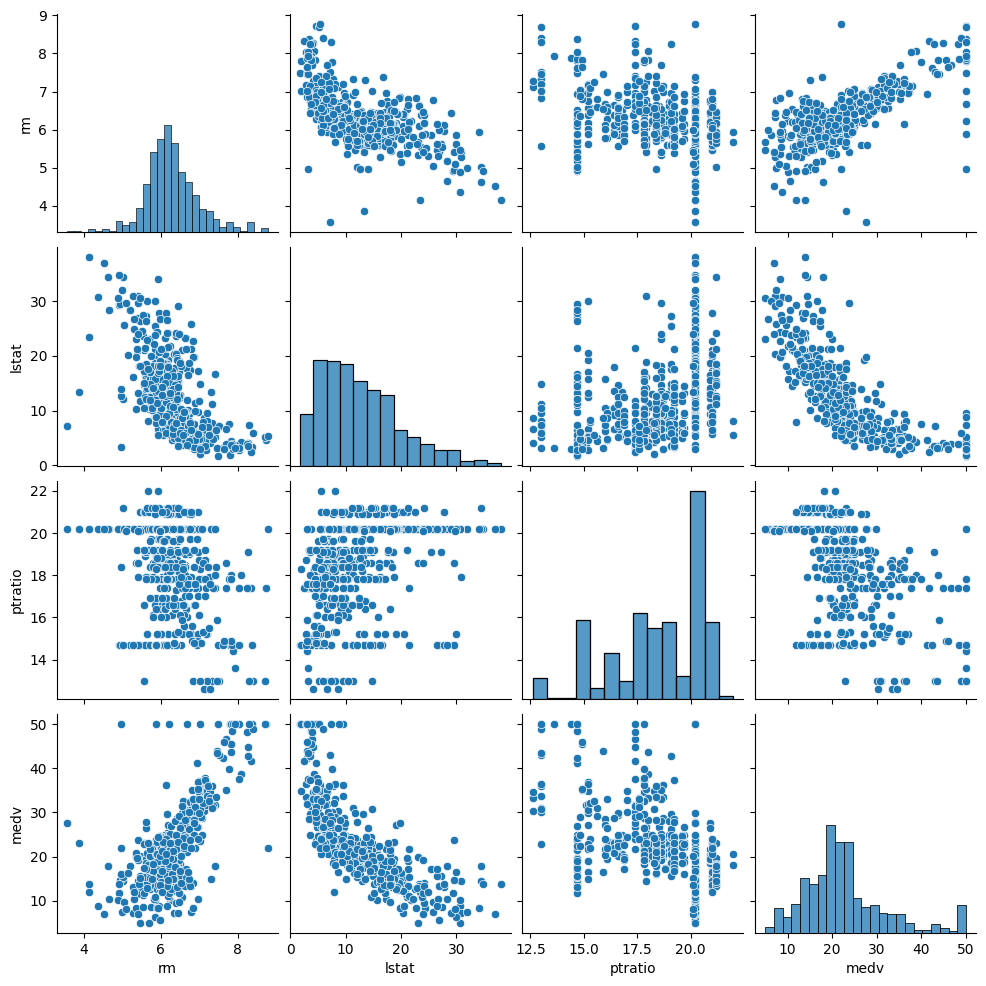

In [7]:
sns.pairplot(df[['rm','lstat','ptratio','medv']])

plt.show()

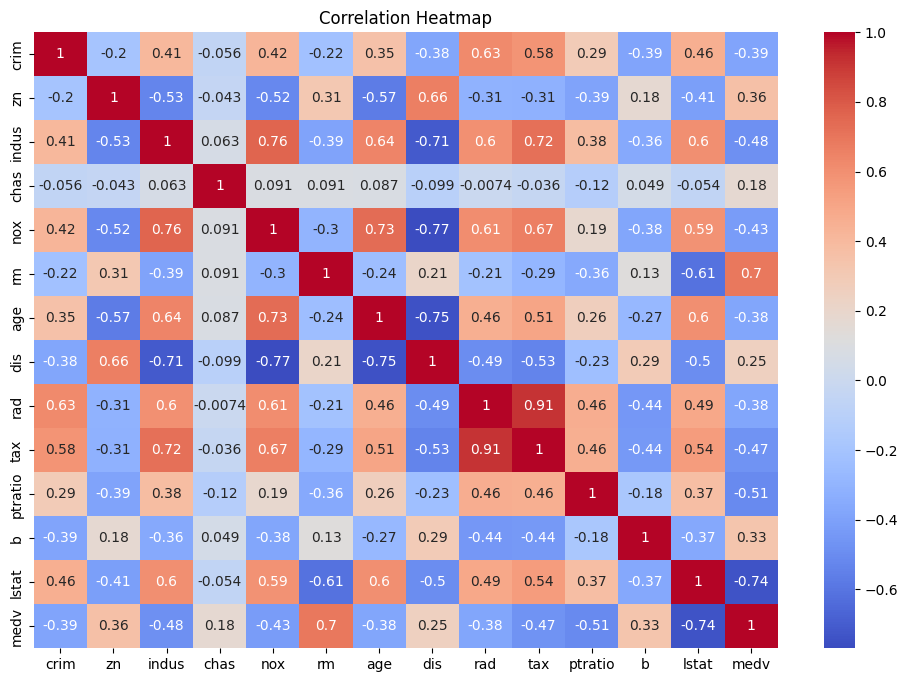

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [9]:
corr=df.corr()["medv"].sort_values(ascending=False)

print(corr)

medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64


**Interpretation**
* rm → Positive correlation (more rooms increase house price).
* lstat → Strong negative correlation.
* ptratio → Negative correlation.
* tax → Negative correlation.

**Q8. Select independent variables (features) and dependent variable (target).**
**Target variable:** **medv (house price)**

In [10]:
X=df.drop("medv",axis=1)

y=df["medv"]

In [11]:
# Independent Variables
X = df.drop("medv", axis=1)

# Dependent Variable
y = df["medv"]

print("Independent Variables (X):")
print(X.head())

print("\nDependent Variable (y):")
print(y.head())

Independent Variables (X):
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  

Dependent Variable (y):
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64


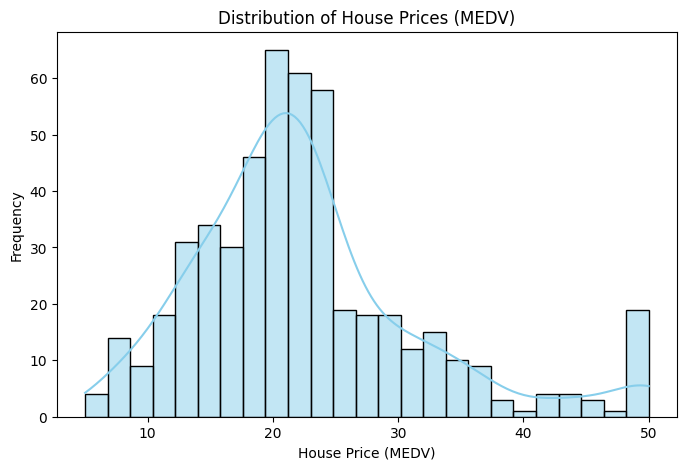

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["medv"], bins=25, kde=True, color="skyblue")

plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("House Price (MEDV)")
plt.ylabel("Frequency")

plt.show()

**Interpretation**
* The histogram shows how house prices are distributed.
* Most houses are concentrated around the middle price range.
* Very high-priced houses are fewer in number.

**Q9. Split the dataset into training and testing sets (80% training, 20% testing).**

In [14]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (404, 13)
Testing Data Shape: (102, 13)


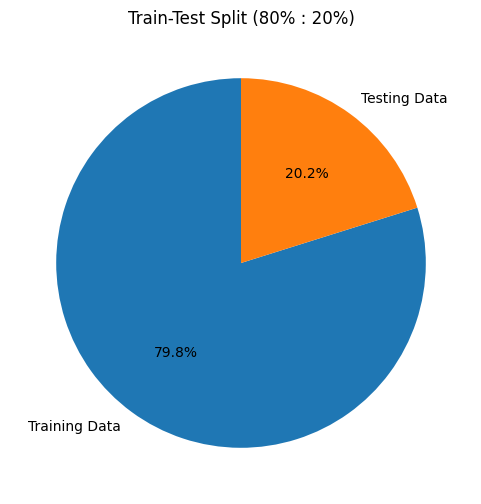

In [16]:
plt.figure(figsize=(6,6))

sizes = [len(X_train), len(X_test)]
labels = ["Training Data", "Testing Data"]

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Train-Test Split (80% : 20%)")

plt.show()

**Interpretation**
* 80% of the dataset is used for training the model.
* 20% is reserved for testing the model.
* This helps evaluate how well the model performs on unseen data.

**Q10. Train a Linear Regression model and perform the following:**
* Make predictions
* Calculate MAE
* Calculate MSE
* Calculate RMSE
* Calculate R² Score
* Calculate Adjusted R²
* Write the Linear Regression equation
* Interpret the model coefficients

**Train Model**

In [17]:
model=LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

**Prediction**

In [18]:
y_pred=model.predict(X_test)

**MAE**

In [19]:
mae=mean_absolute_error(y_test,y_pred)

print("MAE =",mae)

MAE = 3.189091965887837


**MSE**

In [20]:
mse=mean_squared_error(y_test,y_pred)

print("MSE =",mse)

MSE = 24.291119474973478


**RMSE**

In [21]:
rmse=np.sqrt(mse)

print("RMSE =",rmse)

RMSE = 4.928602182665332


**R² Score**

In [22]:
r2=r2_score(y_test,y_pred)

print("R² Score =",r2)

R² Score = 0.6687594935356326


**Adjusted R²**

In [23]:
n=len(y_test)

p=X_test.shape[1]

adj_r2=1-(1-r2)*(n-1)/(n-p-1)

print("Adjusted R² =",adj_r2)

Adjusted R² = 0.619826236898851


**Linear Regression Equation**

In [24]:
print("Intercept =",model.intercept_)

Intercept = 30.24675099392366


In [25]:
coef=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

coef

,Feature,Coefficient
0,crim,-0.113056
1,zn,0.030110
2,indus,0.040381
3,chas,2.784438
4,nox,-17.202633
5,rm,4.438835
6,age,-0.006296
7,dis,-1.447865
8,rad,0.262430
9,tax,-0.010647


In [26]:
equation="MEDV = {:.3f}".format(model.intercept_)

for c,f in zip(model.coef_,X.columns):
    equation += " + ({:.3f} * {})".format(c,f)

print(equation)

MEDV = 30.247 + (-0.113 * crim) + (0.030 * zn) + (0.040 * indus) + (2.784 * chas) + (-17.203 * nox) + (4.439 * rm) + (-0.006 * age) + (-1.448 * dis) + (0.262 * rad) + (-0.011 * tax) + (-0.915 * ptratio) + (0.012 * b) + (-0.509 * lstat)


**Interpretation**
* Positive coefficient → House price increases when that feature increases.
* Negative coefficient → House price decreases when that feature increases.

**For example:**

* **rm** has a positive coefficient, meaning houses with more rooms generally have higher prices.
* **lstat** has a negative coefficient, indicating that higher percentages of lower-status population are associated with lower house prices.
* **crim** has a negative coefficient, suggesting that higher crime rates reduce house prices.
* **dis** has a positive coefficient, indicating that properties farther from employment centers (depending on the model fit) may be associated with higher prices after accounting for other variables.